In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("C:\\Users\\hp\\Documents\\ai-engineering-projects\\week1\\data\\home-credit-default-risk\\application_train.csv")


In [4]:
print(f"dataset shape:{df.shape}")
print(f"number of customers:{df.shape[0]}")
print(f"number of features:{df.shape[1]}")

dataset shape:(307511, 122)
number of customers:307511
number of features:122


In [5]:
print("first 5 customers")
print(df.head())

first 5 customers
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...             

In [6]:
print("\n"+"="*60)
print("column names and types:")
print(df.dtypes)



column names and types:
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object


In [7]:
print("dataset info:")
print(df.info())
print("\nstatistics:")
print(df.describe())


dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None

statistics:
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05   
max    456255.000000       1.000000      19.000000      1.170000e+08   

         AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  3.075110e+05  307499.000000     3.072330e+05   
m

In [8]:
print("Target variable (TARGET):")
print(df['TARGET'].value_counts())
print("\npercentages:")
print(df['TARGET'].value_counts(normalize=True)*100)

Target variable (TARGET):
TARGET
0    282686
1     24825
Name: count, dtype: int64

percentages:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


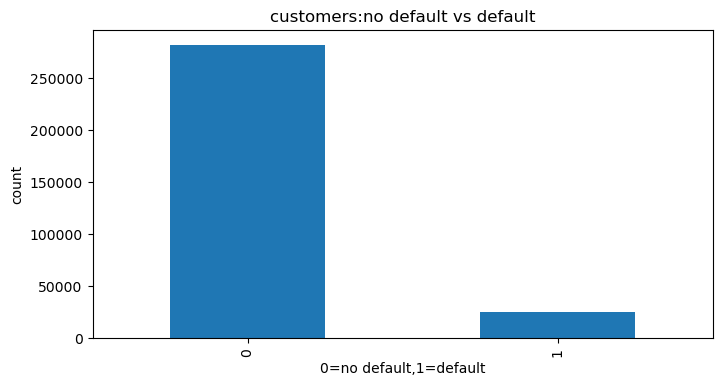

In [10]:
plt.figure(figsize=(8,4))
df['TARGET'].value_counts().plot(kind="bar")
plt.title('customers:no default vs default')
plt.xlabel('0=no default,1=default')
plt.ylabel('count')
plt.show()

In [11]:
missing_data=df.isnull().sum()
print("missing values per column:")
print(missing_data[missing_data>0].sort_values(ascending=False))

missing values per column:
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
                             ...  
EXT_SOURCE_2                   660
AMT_GOODS_PRICE                278
AMT_ANNUITY                     12
CNT_FAM_MEMBERS                  2
DAYS_LAST_PHONE_CHANGE           1
Length: 67, dtype: int64


In [12]:
print("\nPercentage missing:")
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percent[missing_percent > 0])


Percentage missing:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64


In [13]:
print("all features available")
for i,col in enumerate(df.columns):
    print(f"{i}:{col}")

all features available
0:SK_ID_CURR
1:TARGET
2:NAME_CONTRACT_TYPE
3:CODE_GENDER
4:FLAG_OWN_CAR
5:FLAG_OWN_REALTY
6:CNT_CHILDREN
7:AMT_INCOME_TOTAL
8:AMT_CREDIT
9:AMT_ANNUITY
10:AMT_GOODS_PRICE
11:NAME_TYPE_SUITE
12:NAME_INCOME_TYPE
13:NAME_EDUCATION_TYPE
14:NAME_FAMILY_STATUS
15:NAME_HOUSING_TYPE
16:REGION_POPULATION_RELATIVE
17:DAYS_BIRTH
18:DAYS_EMPLOYED
19:DAYS_REGISTRATION
20:DAYS_ID_PUBLISH
21:OWN_CAR_AGE
22:FLAG_MOBIL
23:FLAG_EMP_PHONE
24:FLAG_WORK_PHONE
25:FLAG_CONT_MOBILE
26:FLAG_PHONE
27:FLAG_EMAIL
28:OCCUPATION_TYPE
29:CNT_FAM_MEMBERS
30:REGION_RATING_CLIENT
31:REGION_RATING_CLIENT_W_CITY
32:WEEKDAY_APPR_PROCESS_START
33:HOUR_APPR_PROCESS_START
34:REG_REGION_NOT_LIVE_REGION
35:REG_REGION_NOT_WORK_REGION
36:LIVE_REGION_NOT_WORK_REGION
37:REG_CITY_NOT_LIVE_CITY
38:REG_CITY_NOT_WORK_CITY
39:LIVE_CITY_NOT_WORK_CITY
40:ORGANIZATION_TYPE
41:EXT_SOURCE_1
42:EXT_SOURCE_2
43:EXT_SOURCE_3
44:APARTMENTS_AVG
45:BASEMENTAREA_AVG
46:YEARS_BEGINEXPLUATATION_AVG
47:YEARS_BUILD_AVG
48:COMMONA